In [48]:
# Import necessary libraries
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [38]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [39]:
# Set data directories
train_dir = '/content/drive/MyDrive/Gender/train'
valid_dir = '/content/drive/MyDrive/Gender/validation'

In [40]:
print(os.listdir('/content/drive/MyDrive/Gender/train'))

['women', 'men']


In [41]:
# Set image dimensions and batch size
img_width, img_height = 150, 150
batch_size = 32

In [42]:
# Create data generators for train and valid sets
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir,
                                                    target_size=(150,150),
                                                    batch_size=32,
                                                    class_mode='binary')

valid_generator = valid_datagen.flow_from_directory(valid_dir,
                                                    target_size=(150,150),
                                                    batch_size=32,
                                                    class_mode='binary')

Found 220 images belonging to 2 classes.
Found 80 images belonging to 2 classes.


In [49]:
# Define CNN architecture
model = MobileNetV2(input_shape=(150,150,3),
                          include_top=False,
                          weights='imagenet')

model.trainable = False

x = model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


/tmp/ipykernel_227/3406131400.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(input_shape=(150,150,3),


In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,944,961 (26.49 MB)

 Trainable params: 6,944,001 (26.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [50]:
# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor ='val_loss',
    patience = 3,
    restore_best_weights = True
)

In [51]:
# Train model
history = model.fit(train_generator,
          steps_per_epoch=train_generator.samples // batch_size *5,
          epochs=10,
          validation_data=valid_generator,
          validation_steps=valid_generator.samples // batch_size,
                    callbacks = [early_stop]
                    )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
 6/30 ━━━━━━━━━━━━━━━━━━━━ 1:54 5s/step - accuracy: 0.5422 - loss: 1.1649

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


30/30 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.5521 - loss: 1.0644 - val_accuracy: 0.6094 - val_loss: 0.7108
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 723ms/step - accuracy: 0.6634 - loss: 0.7141 - val_accuracy: 0.8125 - val_loss: 0.4678
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 689ms/step - accuracy: 0.6759 - loss: 0.6551 - val_accuracy: 0.8125 - val_loss: 0.5134
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 648ms/step - accuracy: 0.7567 - loss: 0.5191 - val_accuracy: 0.7500 - val_loss: 0.4738
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 743ms/step - accuracy: 0.8102 - loss: 0.4416 - val_accuracy: 0.7500 - val_loss: 0.5076


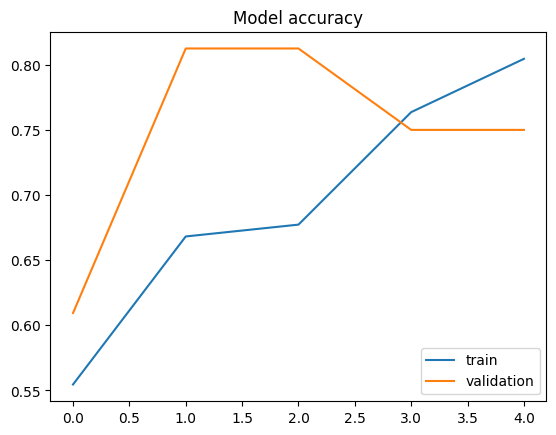

In [52]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.legend(['train','validation'])
plt.show()

In [54]:
# Save model
model.save('/content/drive/MyDrive/Gender/gender_classification_cnn.keras')

In [55]:
import tensorflow as tf

# Load the saved model
model = tf.keras.models.load_model('/content/drive/MyDrive/Gender/gender_classification_cnn.keras')

# Evaluate the model on validation set
valid_loss, valid_acc = model.evaluate(valid_generator, verbose=0)
print('Validation loss:', valid_loss)
print('Validation accuracy:', valid_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Validation loss: 0.4781699776649475
Validation accuracy: 0.824999988079071


In [57]:
# Importing the required libraries
import os
import tensorflow as tf
import numpy as np
import cv2

# Load the pre-trained model for gender classification
model = tf.keras.models.load_model('/content/drive/MyDrive/Gender/gender_classification_cnn.keras')

# Load the image for classification
img = cv2.imread('/content/drive/MyDrive/Gender/validation/women/122.jpg')

# Pre-process the image
img = cv2.resize(img, (150,150))
img = img / 255.0
img = np.expand_dims(img, axis=0)

# Predict the gender of the person in the image
prediction = model.predict(img)
print(prediction)
if prediction < 0.5:
  print("The person in the image is a men.")
else:
  print("The person in the image is a women.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
[[0.87934536]]
The person in the image is a women.


# In this part we use google colab camera to detect


---



In [58]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
from google.colab import output
from base64 import b64decode
from PIL import Image
import tensorflow as tf
import cv2
import numpy as np

# Define function to take photo and classify it
def take_photo_and_classify(model, filename='photo.jpg', quality=0.8):
    # Define JavaScript to open camera and take photo
    js = f'''
        async function takePhoto(quality) {{
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Take photo';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({{video: true}});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          // Resize the output to fit the video element.
          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

          // Wait for Capture to be clicked.
          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }}
        '''

    # Display JavaScript to take photo and capture it
    output.eval_js(js)

    # Retrieve and decode the photo
    data = output.eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)

    # Load the image and preprocess it for classification
    image = Image.open(filename)
    image = image.resize((150, 150))
    image = np.array(image)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)

    # Use the model to classify the image
    prediction = model.predict(image)[0]
    print(prediction)

    # Print the prediction
    if prediction > 0.5:
        print("This person is a woman")
    else:
        print("This person is a man")

# Load the CNN model
model = tf.keras.models.load_model('/content/drive/MyDrive/Gender/gender_classification_cnn.keras')
# Use the take_photo_and_classify function to take a photo and classify it
take_photo_and_classify(model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
[0.72437]
This person is a woman
